# Universidad del Valle de Guatemala
## Abner Iván García Alegría - 21285
## Ludwing Cano - Cifrado de Información
### Laboratorio 3 - Cifrados Simetricos

## Parte 1: Rompiendo ECB en Imágenes

In [20]:
import numpy as np
from PIL import Image
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import matplotlib.pyplot as plt

In [ ]:
def cargar_imagen(nombre_archivo): # Función para cargar una imagen
    """Carga una imagen (PPM o PNG) y la convierte en un array numpy en escala de grises."""
    img = Image.open(nombre_archivo).convert('L') # Convertir a escala de grises
    return np.array(img) # Convertir a un array numpy

In [ ]:
def guardar_imagen(imagen, nombre_archivo): # Función para guardar una imagen
    """Guarda un array numpy como una imagen PNG en escala de grises."""
    img = Image.fromarray(imagen) # Convertir a imagen
    img.save(nombre_archivo) # Guardar imagen

## Cifrado AES con ECB

In [ ]:
def cifrar_aes_ecb(imagen, clave): # Función para cifrar una imagen con AES en modo ECB
    """Cifra una imagen con AES en modo ECB."""
    cipher = AES.new(clave, AES.MODE_ECB) # Crear cifrador AES en modo ECB con la clave dada
    alto, ancho = imagen.shape # Obtener dimensiones de la imagen
    imagen_plana = imagen.flatten().tobytes() # Convertir imagen a bytes
    # Rellenar con bytes para que la longitud sea un múltiplo de 16
    padding = 16 - len(imagen_plana) % 16 # Calcular número de bytes de relleno
    imagen_plana += bytes([padding] * padding) # Rellenar con el número de bytes de relleno
    imagen_cifrada = cipher.encrypt(imagen_plana) # Cifrar imagen con AES en modo ECB
    # Convertir a array numpy y redimensionar
    imagen_cifrada_np = np.frombuffer(imagen_cifrada, dtype=np.uint8) # Convertir a array numpy 
    imagen_cifrada_np = imagen_cifrada_np[:ancho*alto].reshape(alto, ancho) # Redimensionar a imagen original
    return imagen_cifrada_np # Devolver imagen cifrada

## Cifrado con AES con CBC

In [ ]:
def cifrar_aes_cbc(imagen, clave, iv): # Función para cifrar una imagen con AES en modo CBC
    """Cifra una imagen con AES en modo CBC."""
    cipher = AES.new(clave, AES.MODE_CBC, iv) # Crear cifrador AES en modo CBC con la clave y el vector de inicialización dados
    alto, ancho = imagen.shape # Obtener dimensiones de la imagen
    imagen_plana = imagen.flatten().tobytes() # Convertir imagen a bytes
    # Rellenar con bytes para que la longitud sea un múltiplo de 16
    padding = 16 - len(imagen_plana) % 16 # Calcular número de bytes de relleno 
    imagen_plana += bytes([padding] * padding) # Rellenar con el número de bytes de relleno
    imagen_cifrada = cipher.encrypt(imagen_plana) # Cifrar imagen con AES en modo CBC
    # Convertir a array numpy y redimensionar
    imagen_cifrada_np = np.frombuffer(imagen_cifrada, dtype=np.uint8) # Convertir a array numpy
    imagen_cifrada_np = imagen_cifrada_np[:ancho*alto].reshape(alto, ancho) # Redimensionar a imagen original
    return imagen_cifrada_np # Devolver imagen cifrada

### Ejemplo con una mi imagen

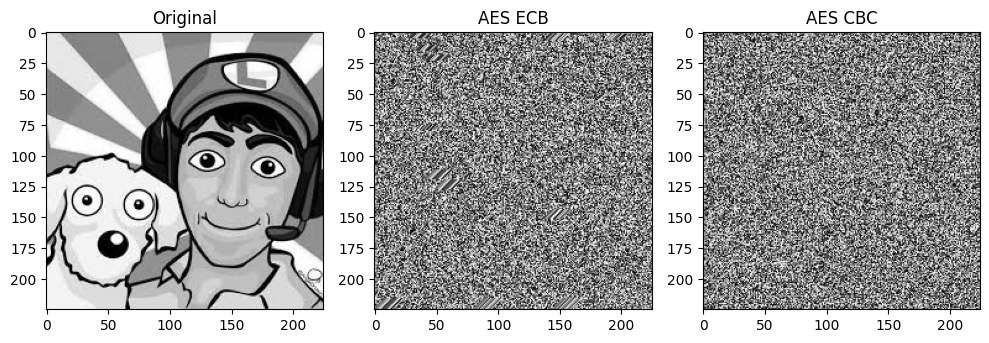

In [ ]:
# Cargar la imagen (puede ser PPM o PNG)
nombre_archivo = input("Ingrese el nombre del archivo de imagen (con extensión): ")  #Permite ingresar el nombre del archivo
imagen_original = cargar_imagen(nombre_archivo)

# Clave AES y vector de inicialización (IV)
clave = get_random_bytes(16)  # 128 bits
iv = get_random_bytes(16)     # 128 bits

# Cifrar con ECB
imagen_ecb_cifrada = cifrar_aes_ecb(imagen_original, clave) # Cifrar la imagen con AES en modo ECB
guardar_imagen(imagen_ecb_cifrada, f'{nombre_archivo.split(".")[0]}_ecb.png') # Guardar la imagen cifrada

# Cifrar con CBC
imagen_cbc_cifrada = cifrar_aes_cbc(imagen_original, clave, iv) # Cifrar la imagen con AES en modo CBC
guardar_imagen(imagen_cbc_cifrada, f'{nombre_archivo.split(".")[0]}_cbc.png') # Guardar la imagen cifrada

# Mostrar las imágenes
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen_original, cmap='gray')
plt.title('Original')

plt.subplot(1, 3, 2)
plt.imshow(imagen_ecb_cifrada, cmap='gray')
plt.title('AES ECB')

plt.subplot(1, 3, 3)
plt.imshow(imagen_cbc_cifrada, cmap='gray')
plt.title('AES CBC')

plt.tight_layout()
plt.show()

### Imagen de prueba con tux
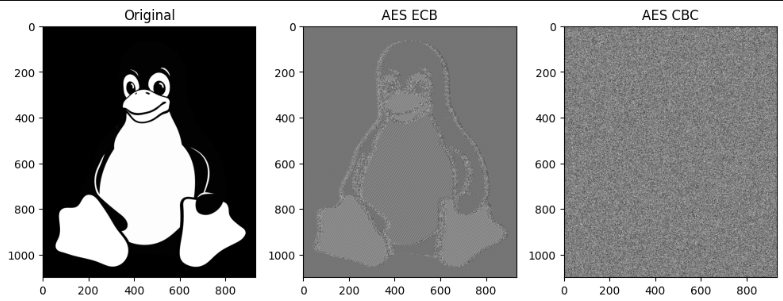

# 🔹 Preguntas para reflexión

• *¿Por qué el cifrado ECB revela los patrones de la imagen?*
  ECB cifra cada bloque de 16 bytes de forma independiente con la misma clave. 
  Si bloques idénticos en la imagen original producen bloques cifrados idénticos. 
  Esto conserva los patrones visuales, especialmente en áreas de color uniforme como podemos ver en las imagenes de prueba vemos que en el cifrado ECB aún se mira la imagen, es decir conserva un poco de la imagen original.

• *¿Cómo cambia la apariencia con CBC?*
  CBC cifra cada bloque combinándolo con el bloque cifrado anterior. 
  Esto rompe los patrones visibles porque los bloques cifrados idénticos en la imagen 
  original producen bloques cifrados diferentes, podemos ver que este es mejor ya que las imagenes de cifrado CBC no podemos ver nada de la imagen original lo cual es perfecto para poder cifrar las imagenes.

• *¿Qué tan seguro es usar ECB para cifrar datos estructurados?*
  ECB es inseguro para datos estructurados debido a la conservación de patrones. 
  Es vulnerable a ataques de reemplazo de bloques y no debe usarse para datos confidenciales.

# Parte 2: Capturando Cifrado en Red con Wireshark

### Parte trabajada con Oscar Esteban Donis -21610
Crear un script que envíe mensajes cifrados con AES-CBC a un servidor.(Los scripts estan en la carpeta parte2 se llaman socket_client.py y socket_server.py)

## Imagenes de pruebas
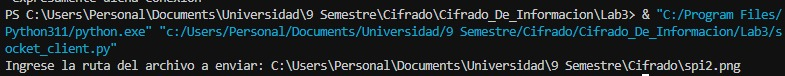

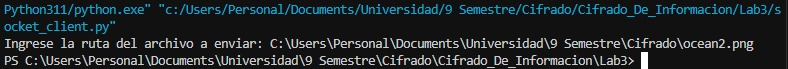

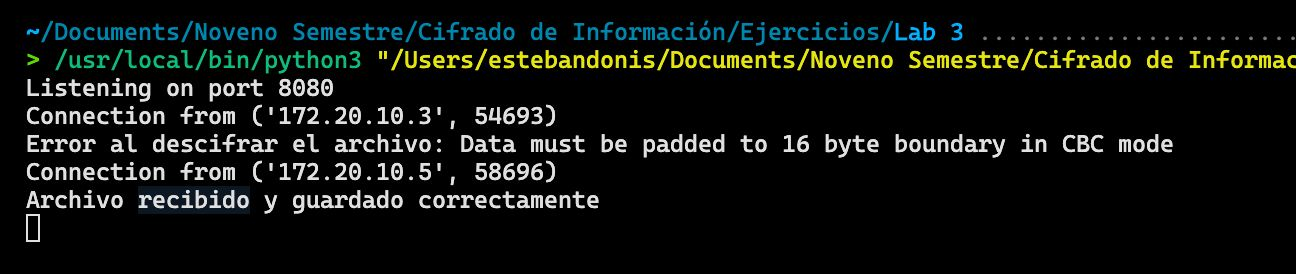

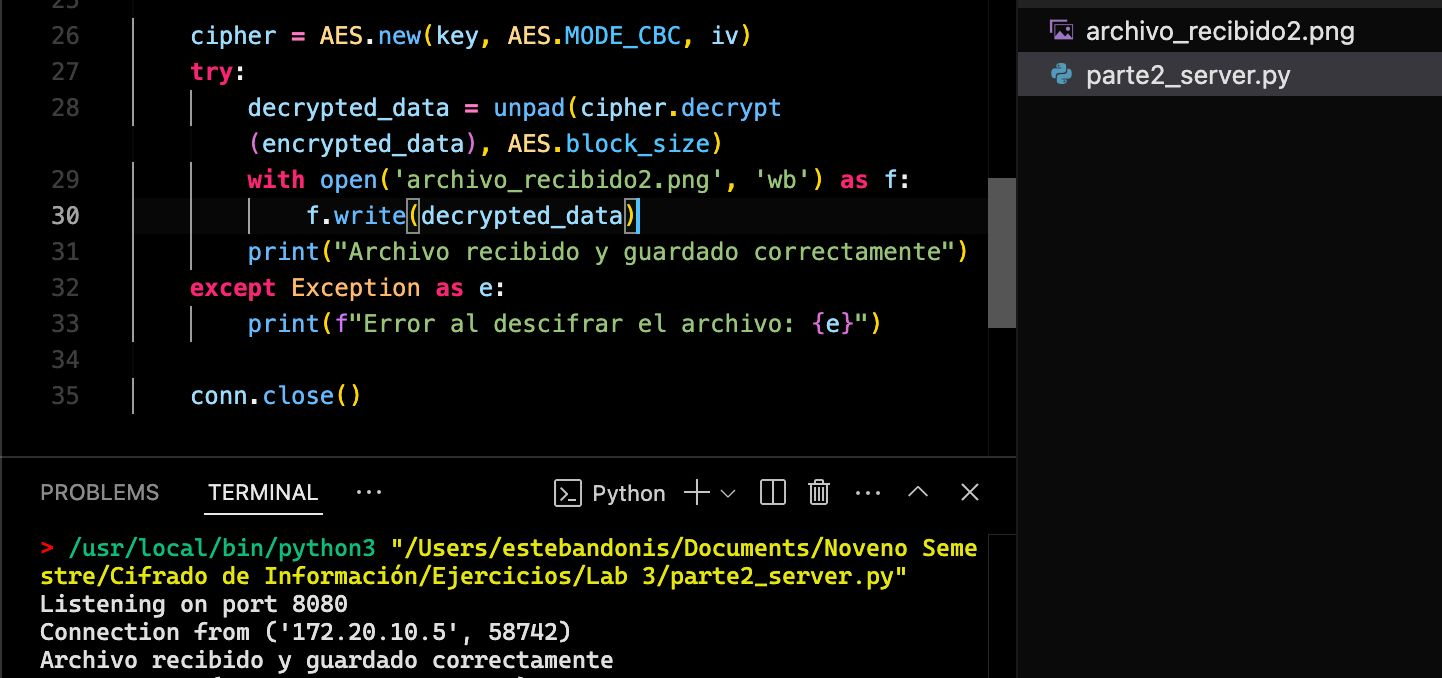

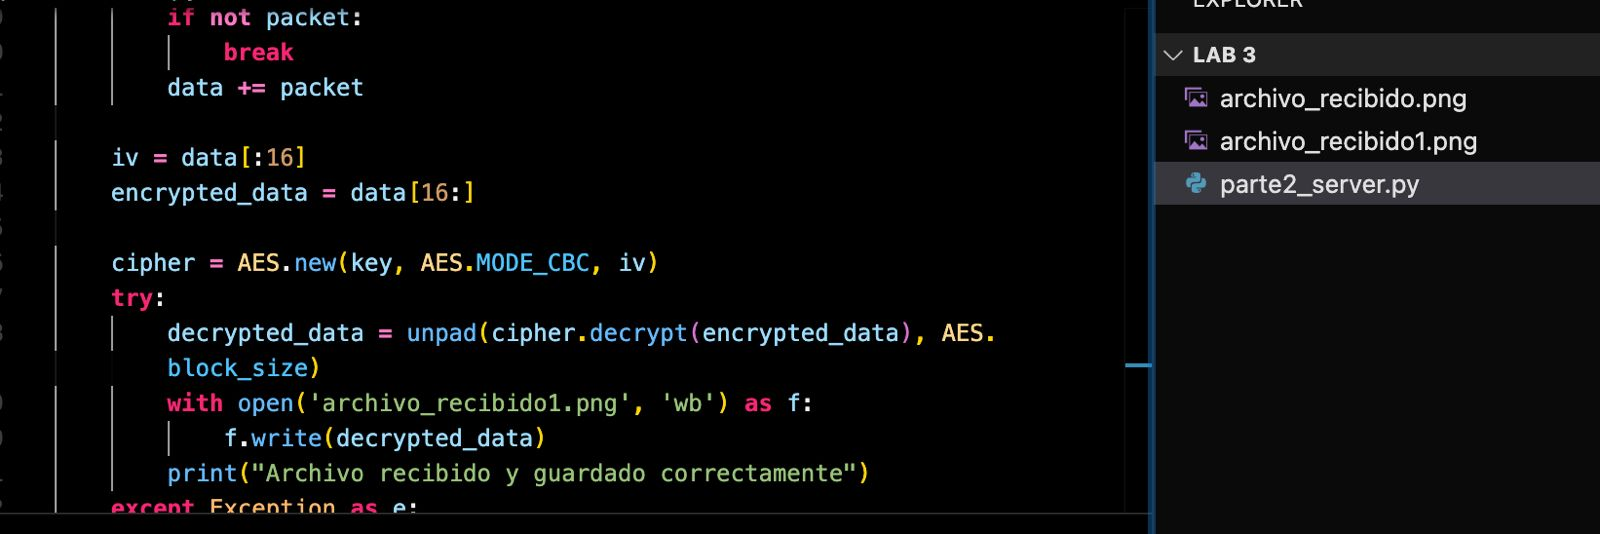

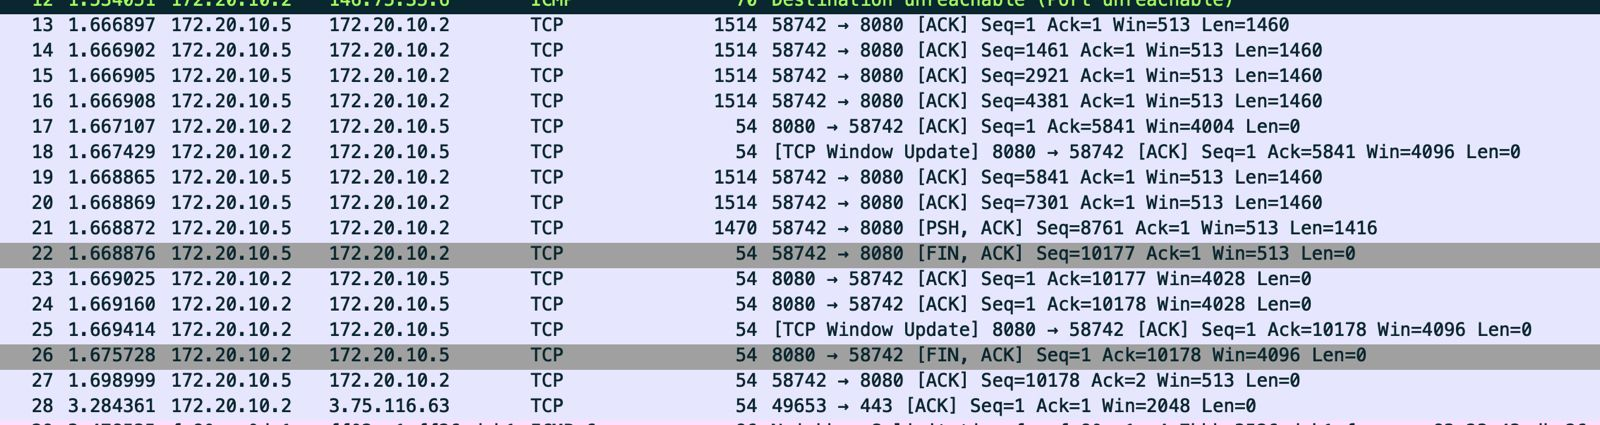

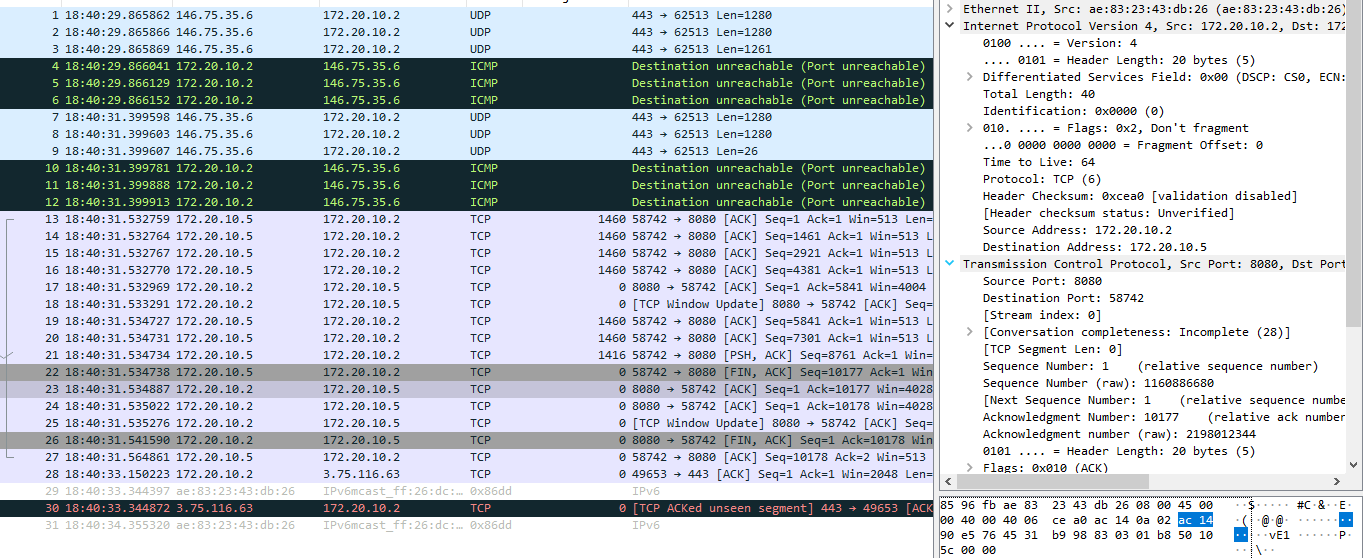

# 🔹 Preguntas para reflexión

• *¿Se puede identificar que los mensajes están cifrados con AES-CBC?*
No se puede determinar de forma concluyente que los mensajes están cifrados específicamente con AES-CBC. Wireshark permite observar el flujo de paquetes, direcciones IP y puertos, pero el contenido cifrado dentro de esos paquetes aparece como datos aleatorios. La presencia de datos aparentemente aleatorios sugiere que se está utilizando algún tipo de cifrado, pero no revela el algoritmo exacto. Aunque el modo CBC introduce un vector de inicialización (IV), que influye en la variabilidad del cifrado, la simple observación del tráfico no es suficiente para aislar AES-CBC como el método de cifrado empleado, ya que otros algoritmos y modos de cifrado pueden producir resultados similares.

• *¿Cómo podríamos proteger más esta comunicación?*
Para reforzar la seguridad de esta comunicación más allá del cifrado básico, es fundamental implementar HTTPS/TLS. Esta capa adicional proporciona autenticación y cifrado robusto, asegurando que los datos transmitidos estén protegidos contra interceptaciones y manipulaciones. La implementación de certificados digitales válidos, emitidos por una autoridad de certificación confiable, es crucial para verificar la identidad del servidor y prevenir ataques de intermediarios. Además, Para una protección aún mayor, se podría considerar el cifrado de extremo a extremo, donde los datos se cifran en el dispositivo del remitente y se descifran solo en el del destinatario, asegurando la confidencialidad incluso si el tráfico es interceptado. Finalmente, mantener los protocolos de seguridad actualizados y considerar el uso de una VPN añadiría capas adicionales de protección.

# Parte 3: Implementando un Cifrado de Flujo con ChaCha20